In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/data.csv', encoding='latin1')
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('[^a-z0-9_]', '', regex=True)
)

# Visualizar primeiras linhas
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
# Tipos e não-nulos
df.info()

# Estatísticas descritivas das variáveis numéricas
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    541909 non-null  object 
 1   stockcode    541909 non-null  object 
 2   description  540455 non-null  object 
 3   quantity     541909 non-null  int64  
 4   invoicedate  541909 non-null  object 
 5   unitprice    541909 non-null  float64
 6   customerid   406829 non-null  float64
 7   country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,quantity,unitprice,customerid
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


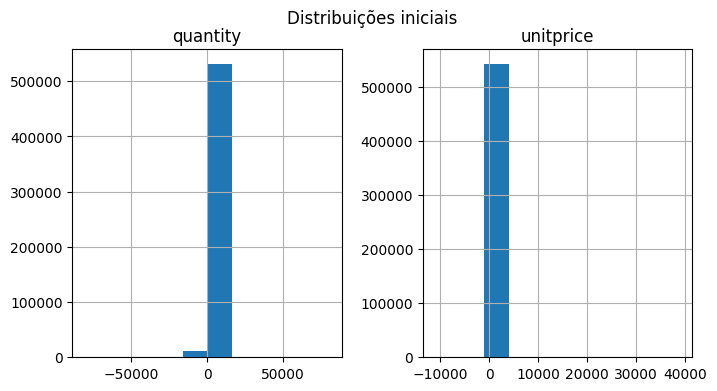

In [ ]:
import matplotlib.pyplot as plt

# Histogramas de quantity e unitprice
df[['quantity','unitprice']].hist(figsize=(8,4))
plt.suptitle('Distribuições iniciais')
plt.show()


In [ ]:
# Valores faltantes por coluna
print(df.isna().sum())

# Registros duplicados
print(f"Duplicados: {df.duplicated().sum()}")


invoiceno           0
stockcode           0
description      1454
quantity            0
invoicedate         0
unitprice           0
customerid     135080
country             0
dtype: int64
Duplicados: 5268


In [ ]:
df = df.drop_duplicates()
df = df.dropna(subset=['customerid'])


In [ ]:
import datetime as dt

df['invoicedate'] = pd.to_datetime(df['invoicedate'])
snapshot_date = df['invoicedate'].max() + dt.timedelta(days=1)

rfm = df.groupby('customerid').agg({
    'invoicedate': lambda x: (snapshot_date - x.max()).days,
    'invoiceno': 'count',
    'unitprice': lambda x: (x * df.loc[x.index, 'quantity']).sum()
})
rfm.columns = ['recency','frequency','monetary']


In [ ]:
for col in ['recency','frequency','monetary']:
    Q1 = rfm[col].quantile(0.25)
    Q3 = rfm[col].quantile(0.75)
    IQR = Q3 - Q1
    rfm = rfm[(rfm[col] >= Q1 - 1.5*IQR) & (rfm[col] <= Q3 + 1.5*IQR)]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['recency','frequency','monetary']])


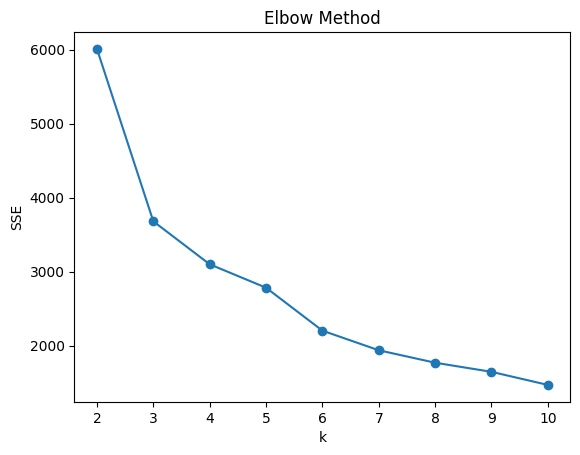

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
k_values = range(2,11)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(rfm_scaled)
    sse.append(km.inertia_)

plt.plot(k_values, sse, 'o-')
plt.title('Elbow Method')
plt.xlabel('k')
plt.ylabel('SSE')
plt.show()


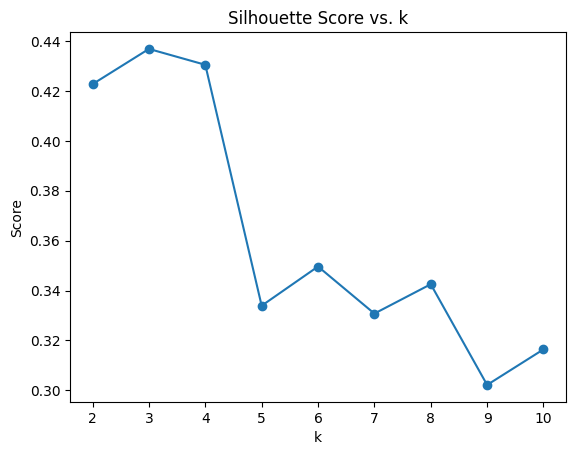

In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in k_values:
    labels = KMeans(n_clusters=k, random_state=42).fit_predict(rfm_scaled)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

plt.plot(k_values, sil_scores, 'o-')
plt.title('Silhouette Score vs. k')
plt.xlabel('k')
plt.ylabel('Score')
plt.show()


In [ ]:
best_k = 4  # definido a partir dos gráficos
model = KMeans(n_clusters=best_k, random_state=42)
rfm['cluster'] = model.fit_predict(rfm_scaled)


In [ ]:
summary = (
    rfm.groupby('cluster')
       .agg({'recency':'mean','frequency':'mean','monetary':'mean','cluster':'count'})
       .rename(columns={'cluster':'count'})
       .round(2)
)
print(summary)


         recency  frequency  monetary  count
cluster                                     
0          40.74     148.20   1015.09    280
1         230.70      22.86    358.06    892
2          43.76      91.66   1860.58    621
3          49.15      31.96    506.63   1750


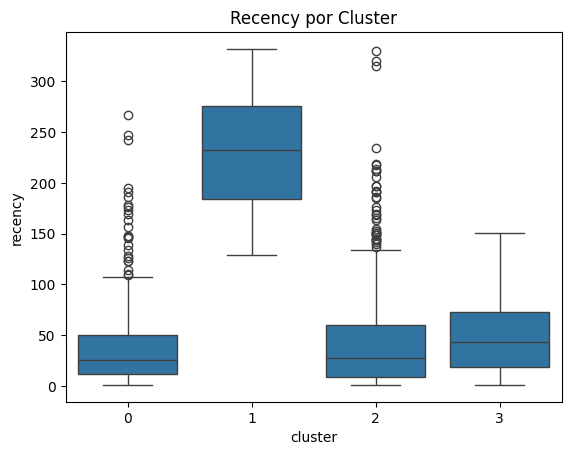

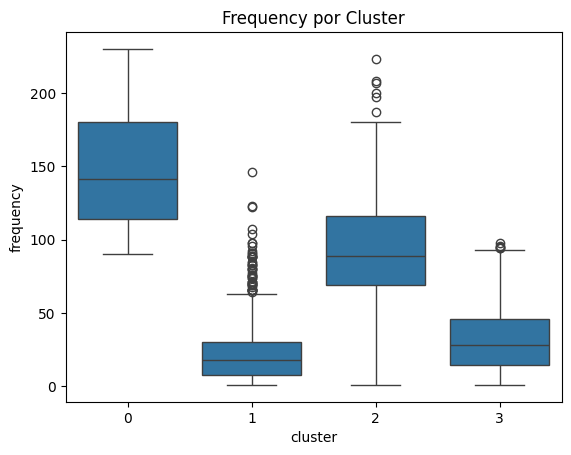

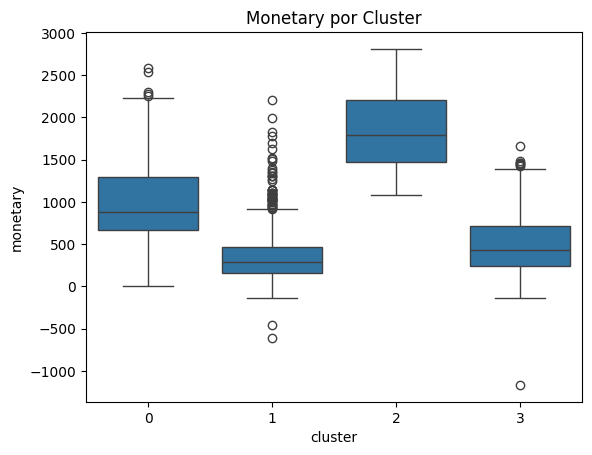

In [ ]:
import seaborn as sns

for col in ['recency','frequency','monetary']:
    plt.figure()
    sns.boxplot(x='cluster', y=col, data=rfm.reset_index())
    plt.title(f'{col.capitalize()} por Cluster')
    plt.show()


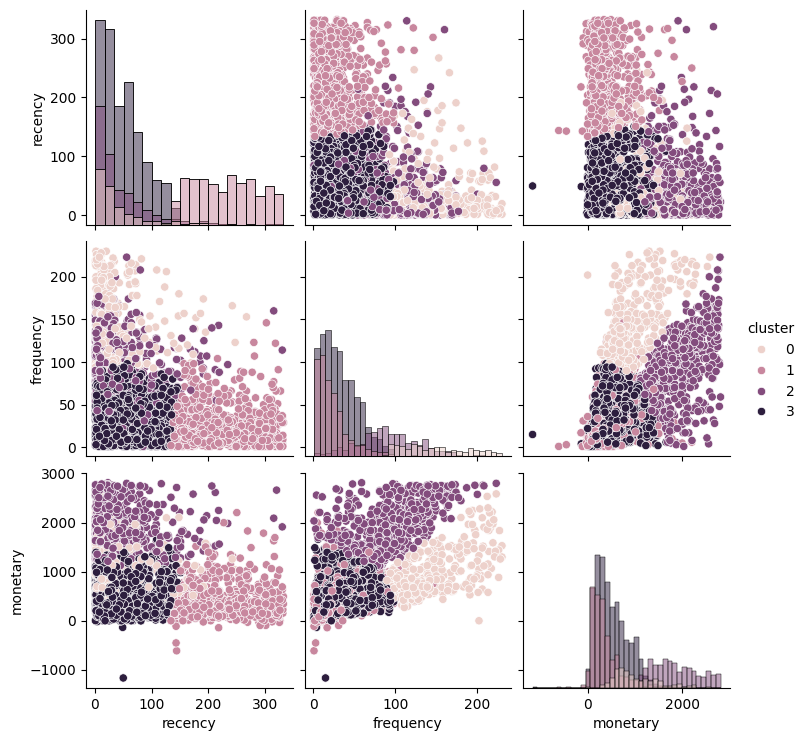

In [ ]:
sns.pairplot(rfm.reset_index(), vars=['recency','frequency','monetary'], hue='cluster', diag_kind='hist')
plt.show()


In [ ]:
profiles = {
    0: 'Champions: baixa Recency, alta Frequency e Monetary',
    1: 'At Risk: alta Recency, média Frequency e Monetary',
    2: 'Need Attention: média Recency, baixa Frequency e Monetary',
    3: 'Potential Loyalists: baixa Recency, média Frequency e Monetary'
}
for cl, desc in profiles.items():
    print(f'Cluster {cl}: {desc}')


Cluster 0: Champions: baixa Recency, alta Frequency e Monetary
Cluster 1: At Risk: alta Recency, média Frequency e Monetary
Cluster 2: Need Attention: média Recency, baixa Frequency e Monetary
Cluster 3: Potential Loyalists: baixa Recency, média Frequency e Monetary


# **Justificativas das Tomadas de Decisão**

###**Etapa 01 – EDA Padronização das colunas:**

*   facilita o tratamento posterior e evita conflitos com nomes que contêm espaços ou símbolos.
*   Verificação de nulos e duplicados: assegura integridade e evita vieses nos resultados de clusterização.
*   Análise estatística e visual: permite conhecer a distribuição, detectar valores atípicos e avaliar se transformações são necessárias.

###**Etapa 02 – Pré-processamento**

*   Remoção de duplicados e customerid nulos: clientes sem ID não podem ser agrupados; duplicações podem distorcer a análise.
*   Cálculo do RFM: essa técnica é amplamente utilizada em segmentação de clientes e resume o comportamento de compra em 3 dimensões simples, porém poderosas.
*   Remoção de outliers via IQR: melhora a performance dos algoritmos baseados em distância, como K-Means, evitando distorções.
*   Normalização: padroniza as variáveis para que tenham igual influência no modelo (sem isso, a variável monetary, por exemplo, teria peso desproporcional).

###**Etapa 03 – Algoritmo de Clusterização**
* Escolha do K-Means: é eficiente e adequado quando o número de clusters é conhecido ou estimado. Ele se adapta bem à estrutura esférica e é muito usado com RFM.
* Uso do método do cotovelo e silhouette score: técnicas complementares para encontrar um “k” ótimo com base na variabilidade e separabilidade dos grupos.

###**Etapa 04 – Análise dos Clusters**
* Boxplots e pairplots: auxiliam na visualização e comparação entre os clusters em cada dimensão da RFM.
* Resumo estatístico por cluster: permite interpretar e rotular os grupos de forma mais objetiva.

###**Etapa 05 – Interpretação**
* Perfis baseados em RFM: o mapeamento de perfis como “Champions” ou “At Risk” segue padrões estabelecidos por boas práticas de CRM (Customer Relationship Management).



#**Propostas Coerentes com os Clusters Encontrados**

 ### **Cluster 0: Champions**

**Características:**
Alta frequência, alto gasto e baixa recência.

**Propostas:**

*   Campanhas VIP exclusivas.
*   Programas de fidelidade com recompensas premium.
*   Convites para eventos ou lançamentos em primeira mão.

### **Cluster 1: At Risk**

**Características:**

Alta recência (não compram há muito tempo), valores ainda razoáveis.

**Propostas:**

*   Campanhas de reativação com cupons de desconto ou benefícios por tempo limitado.
*   Pesquisas para entender os motivos do afastamento.
*   E-mails personalizados lembrando de produtos comprados anteriormente.



### **Cluster 2: Need Attention**

**Características:**

Clientes que compram pouco, com valores baixos e frequência reduzida.

**Propostas:**

*   Campanhas educativas e tutoriais para familiarização com os produtos.
*   Ofertas de baixo risco (frete grátis, amostras).
*   Remarketing com foco em experiências positivas de outros usuários.

### **Cluster 3: Potential Loyalists**

**Características:**

Boa frequência, valores medianos, recência baixa.

**Propostas:**

*   Incentivos à fidelização (acúmulo de pontos, gamificação).
*   Sugestões de produtos com base em compras anteriores.
*   Follow-ups pós-compra com promoções exclusivas.